# set up

In [202]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [203]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 3 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [199]:
# Load selected group_id
import pickle
with open('group_id_selected_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_selected_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [204]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [319]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [111]:
# Just to get a wider range of speed
start_time = -0.5
end_time = 1.0
padding = 0
V1_wider = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeC','probeD','probeE'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

V1_wider.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)


## No speed

Negative log likelihood is: 67216.38
aic/2 is: 67246.38


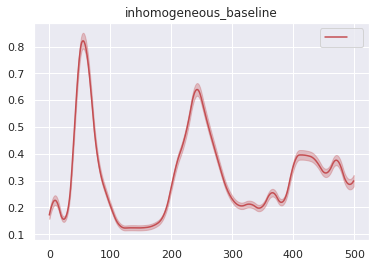

In [205]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Simple linear term of speed

Negative log likelihood is: 67013.92
aic/2 is: 67044.92


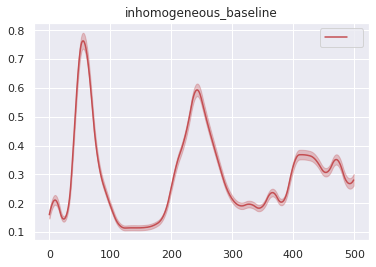

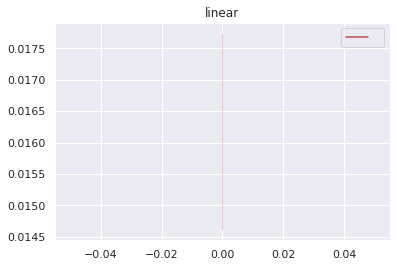

In [206]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Simple binary term of state

Negative log likelihood is: 67069.93
aic/2 is: 67100.93


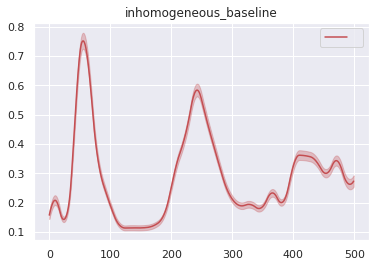

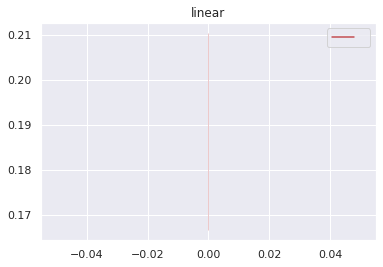

In [207]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
threshold = 1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

Negative log likelihood is: 66296.67
aic/2 is: 66356.67


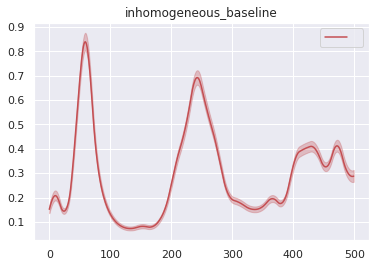

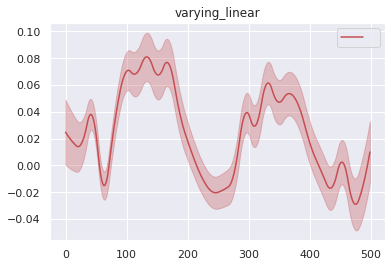

In [208]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Time-varying binary term of state

Negative log likelihood is: 66173.74
aic/2 is: 66233.74


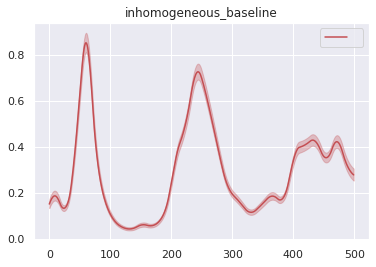

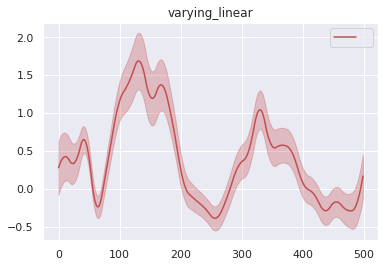

In [209]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Trial-wise binary term of state

Negative log likelihood is: 65917.74
aic/2 is: 65977.74


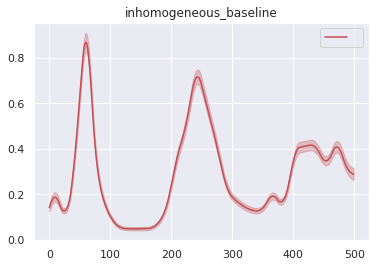

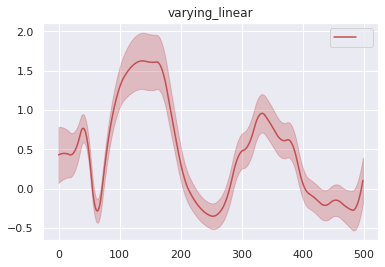

In [210]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

## Two-way couping

Negative log likelihood is: 67003.12
aic/2 is: 67038.12


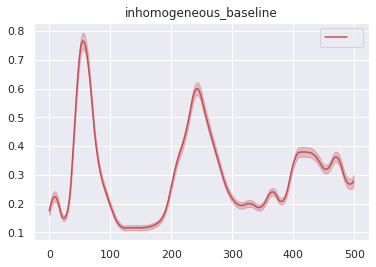

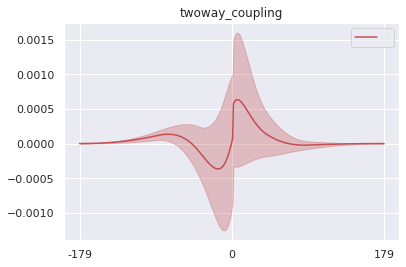

In [224]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4)
model.fit('probeC', verbose=True)
GLM.plot_GLM_compare(model)

# Fit six areas with 14 conditions

## Set up

In [225]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [412]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide couping filter hyperparameters

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

In [353]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear)
for j, input_probe in enumerate(probe_list):
    if j==2:
        continue
    model.add_effect('coupling', probe_list[j], peaks_max=50, num=6, nonlinear=0.3)
model.fit('probeC', verbose=True)

Negative log likelihood is: 61980.41
aic/2 is: 62070.41


In [584]:
ntrial = 30
neuron1 = [V1.spike_train.iloc[55,i] for i in range(V1.ntrial)]
neuron1 = np.vstack(neuron1).T[:,0:ntrial]
neuron2 = [V1.spike_train.iloc[130,i] for i in range(V1.ntrial)]
neuron2 = np.vstack(neuron2).T[:,0:ntrial]

In [596]:
select_trials = np.full(V1.ntrial, False)
select_trials[0:ntrial] = True
num_basis_baseline = 10

peaks_max_list = np.arange(1,151,5)
history_length_0 = np.zeros_like(peaks_max_list)
result_0 = np.zeros_like(peaks_max_list)
for i, peaks_max in enumerate(peaks_max_list):
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    model.add_effect('coupling', neuron1 , peaks_max=peaks_max, num=20, nonlinear=1)
    model.fit(neuron2, verbose=False)
    result_0[i] = model.aic
    history_length_0[i] = model.basis_list[1].shape[0]
    

history_length_1 = np.zeros_like(peaks_max_list)
result_1 = np.zeros_like(peaks_max_list)
for i, peaks_max in enumerate(peaks_max_list):
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
    model.add_effect('dense_coupling', neuron1 , peaks_max=peaks_max, num=peaks_max, nonlinear=1)
    model.fit(neuron2, verbose=False)
    result_1[i] = model.aic
    history_length_1[i] = model.basis_list[1].shape[0]

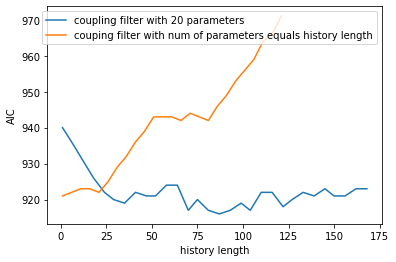

In [606]:
plt.plot(history_length_0, result_0, label="coupling filter with 20 parameters")
plt.plot(history_length_1[:25], result_1[:25], label="couping filter with num of parameters equals history length")
plt.ylabel('AIC')
plt.xlabel('history length')
plt.legend()

## Fit

In [354]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

## Excursion test

In [12]:
# Non multiprocessing verison of null distribution
n_null = 10

import copy
fake_running_trial_index = copy.deepcopy(V1.running_trial_index)
statistics_null = {}

for i_null in tqdm(range(n_null)):
    np.random.shuffle(fake_running_trial_index)  
    # don't need to assign shuffled list, it's changed automatically. 
    fake_stationary_trial_index = np.logical_not(fake_running_trial_index)
    running_filter_temp = {}
    stationary_filter_temp = {}
    
    for i, target_probe in enumerate(probe_list):
        select_trials = fake_running_trial_index
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            model.add_effect('coupling', probe_list[j], peaks_max=100, num=5, nonlinear=0.3)
        model.fit(probe_list[i], verbose=False)
        filter_list = model.get_filter(ci=True)
        running_filter_temp[i,-1] = filter_list[0]
        k = 1
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            running_filter_temp[i,j] = filter_list[k]
            k += 1

        select_trials = fake_stationary_trial_index
        model = GLM.PP_GLM(dataset=V1, 
                           select_trials=select_trials, 
                           membership=membership, 
                           condition_ids=condition_ids)
        model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            model.add_effect('coupling', probe_list[j], peaks_max=100, num=5, nonlinear=0.3)
        model.fit(probe_list[i], verbose=False)
        filter_list = model.get_filter(ci=True)
        stationary_filter_temp[i,-1] = filter_list[0]
        k = 1
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            stationary_filter_temp[i,j] = filter_list[k]
            k += 1

        filter_index = i,-1
        function1 = np.exp( running_filter_temp[filter_index][0] )
        function2 = np.exp( stationary_filter_temp[filter_index][0] )
        if filter_index not in statistics_null.keys():
            statistics_null[filter_index] = []
        statistics_null[filter_index].append( get_excursion_test(function1, function2, ROI[filter_index]) )
        
        for j, input_probe in enumerate(probe_list):
            if i==j:
                continue
            filter_index = i,j
            function1 = running_filter_temp[filter_index][0]
            function2 = stationary_filter_temp[filter_index][0]
            if filter_index not in statistics_null.keys():
                statistics_null[filter_index] = []
            statistics_null[filter_index].append( get_excursion_test(function1, function2, ROI[filter_index]) )

100%|███████████████████████████████████████████| 10/10 [02:00<00:00, 12.04s/it]


In [356]:
from GLM import get_statistics_null_mp
statistics_null = get_statistics_null_mp(1000, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=50


100%|█████████████████████████████████████| 1000/1000 [1:06:39<00:00,  4.00s/it]


## Results with excursion test

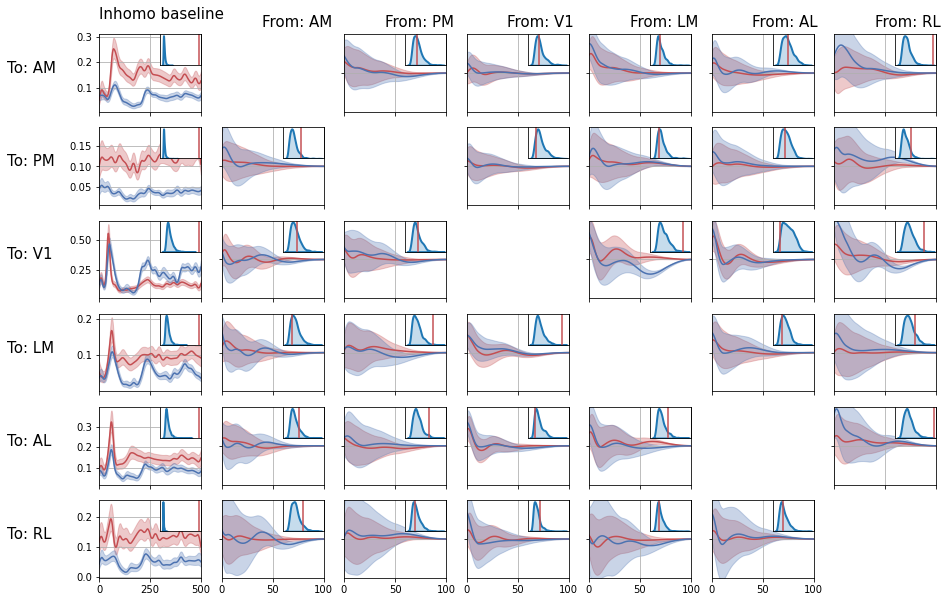

In [361]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(40, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        ins = ax.inset_axes([0.6,0.6,0.4,0.4])
        sns.kdeplot(statistics_null[filter_index], linewidth=2, ax=ins, fill=True)
        ins.axvline(statistics[filter_index], linewidth=1.5, color='r')
        ins.set_xticks([])
        ins.set_yticks([])
        ins.set_ylabel('')
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0, 0.37, f'Inhomo baseline', fontsize=fontsize)



# Contributions of each effect

In [362]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_output(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI[filter_index] = GLM.get_ROI(function1, function2)
    statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI[filter_index] = GLM.get_ROI(function1, function2)
        statistics[filter_index] = GLM.get_excursion_test(function1, function2, ROI[filter_index])

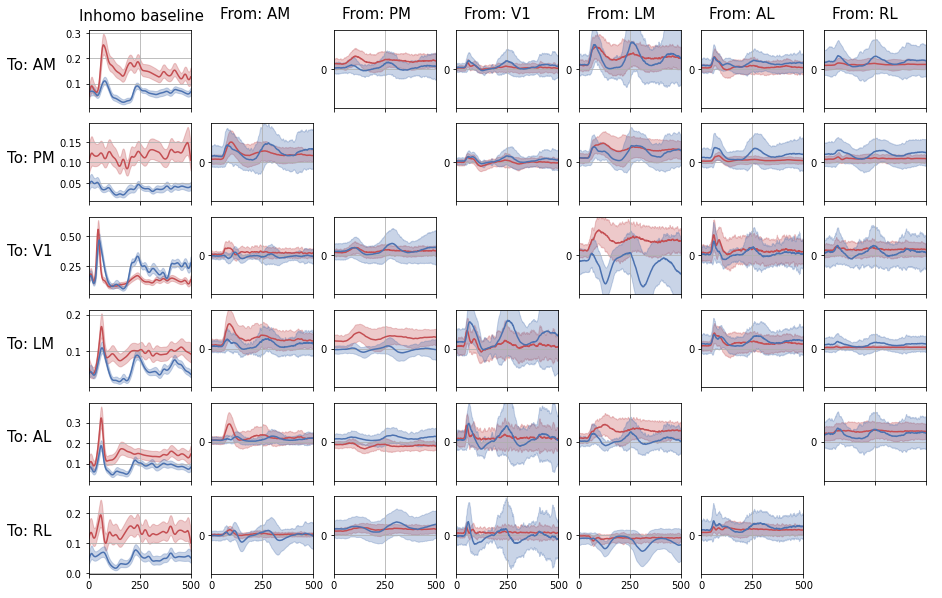

In [378]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize=15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        if i==j:
            continue
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-1, 1])
#             plt.yticks(color='w')
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            if i==0:
                plt.text(40, 1.3, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-1000, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-2200, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 3.7, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-50, 0.35, f'Inhomo baseline', fontsize=fontsize)


# Plot graphs

Possible inference to do:

inference on filters: 

(abondon for now because most filters are the same under running and stationary conditions)\
H0: a coupling filter is all zeros\
Do simulation under null. Test statistics can be excursion, or just sum(abs(filter))\
In this way we get p-value that tells how significant this filter is\

inference on an effect's output: \
first average across trials then calculate KS/KL/Wasserstein from a uniform distribution\
calculate {(KS of all effects sum)-(KS of all without the i-th effect's output)} \
bootstrap 1000 times

## log p-value of excursion test graph

Doesn't seem very useful. But it's a good way to add simulation and parametric bootstrap under null. 

## KL divergence (amount of information) graph

### all peaks

In [764]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.35]

probe_list = V1.selected_probes
running = {}
stationary = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    running[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    stationary[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary[i,j] = filter_list[k]
        k += 1
    


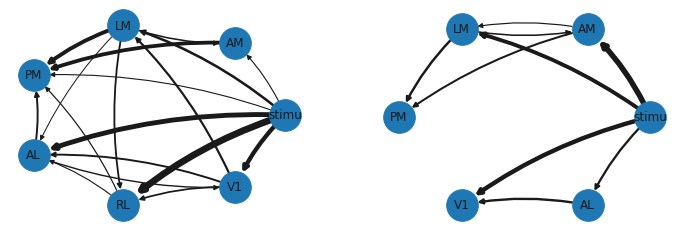

In [772]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.01
plot_amp = 100

import networkx as nx

plt.subplots(figsize=(12,4))
plt.subplot(1,2,1)
to_plot_result = stationary
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

### peak 1

In [773]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.0, 0.15]

probe_list = V1.selected_probes
running = {}
stationary = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    running[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    stationary[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary[i,j] = filter_list[k]
        k += 1
    


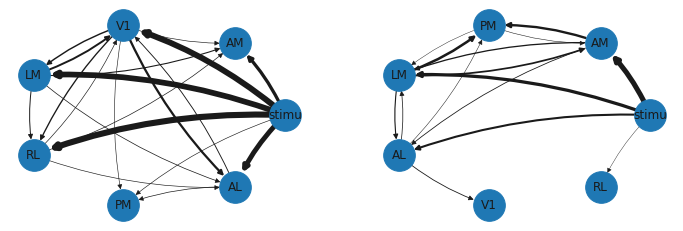

In [776]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.01
plot_amp = 40

import networkx as nx

plt.subplots(figsize=(12,4))
plt.subplot(1,2,1)
to_plot_result = stationary
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)

### peak 2

In [777]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
time_range = [0.15, 0.35]

probe_list = V1.selected_probes
running = {}
stationary = {}
ROI = {}
statistics = {}

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    running[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        running[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        model.add_effect('coupling', probe_list[j], **coupling_filter_params)
    model.fit(probe_list[i], verbose=False)
    filter_list = model.get_filter_contribution(time_range=time_range)
    stationary[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        if i==j:
            continue
        stationary[i,j] = filter_list[k]
        k += 1
    


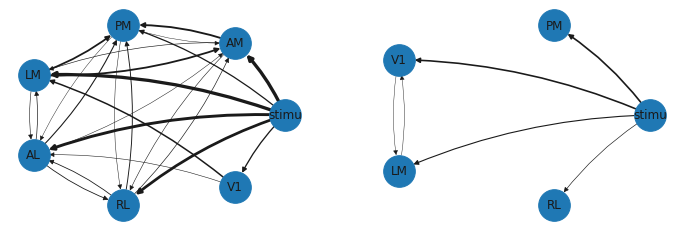

In [778]:
measure_type = 1    # KL:0, KS:1, Wasser:2
plot_thres = 0.01
plot_amp = 40

import networkx as nx

plt.subplots(figsize=(12,4))
plt.subplot(1,2,1)
to_plot_result = stationary
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


plt.subplot(1,2,2)
to_plot_result = running
G = nx.DiGraph()
name_dict = {-1:"stimu", 0:"AM", 1:"PM", 2:"V1", 3:"LM", 4:"AL", 5:"RL"}
for pair, value in to_plot_result.items():
    if value[measure_type] >= plot_thres:
        G.add_edge(name_dict[pair[1]], name_dict[pair[0]], weight=(value[measure_type]*plot_amp))

pos = nx.circular_layout(G)

edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]
edge_labels = nx.get_edge_attributes(G, "weight")
for key, value in edge_labels.items():
    edge_labels[key] = round(edge_labels[key]/plot_amp,3)


nx.draw(G, pos, with_labels=True, node_size=1000, width=weights, connectionstyle='arc3, rad = 0.1')
# nx.draw_networkx_edge_labels(G, pos, edge_labels)


In [782]:
from collections import deque
aaa = deque([1,2,3])
aaa[0:2]

TypeError: sequence index must be integer, not 'slice'

In [785]:
aaa = queue.Queue([1,2,3])
len(aaa)

TypeError: object of type 'Queue' has no len()